In [1]:
!pip install opencv-python-headless scikit-image matplotlib

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\msys64\mingw64\bin\pip.exe\__main__.py", line 4, in <module>
  File "C:\msys64\mingw64\lib\python3.11\site-packages\pip\_internal\cli\main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "C:\msys64\mingw64\lib\python3.11\site-packages\pip\_internal\cli\autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "C:\msys64\mingw64\lib\python3.11\site-packages\pip\_internal\cli\main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
ModuleNotFoundError: No module named 'pip._internal.build_env'


In [2]:
!pip install scikit-learn

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\msys64\mingw64\bin\pip.exe\__main__.py", line 4, in <module>
  File "C:\msys64\mingw64\lib\python3.11\site-packages\pip\_internal\cli\main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "C:\msys64\mingw64\lib\python3.11\site-packages\pip\_internal\cli\autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "C:\msys64\mingw64\lib\python3.11\site-packages\pip\_internal\cli\main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
ModuleNotFoundError: No module named 'pip._internal.build_env'


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from skimage.measure import regionprops

In [5]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

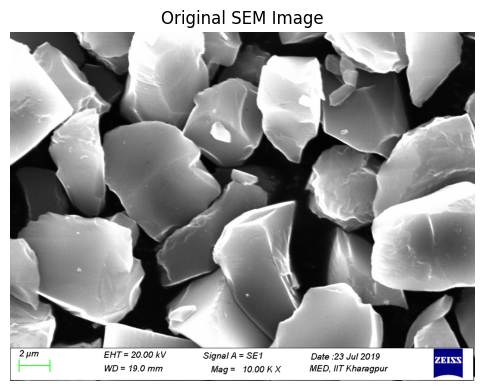

In [ ]:
original_image = cv2.imread(list(uploaded.keys())[0])
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(original_image)
plt.title("Original SEM Image")
plt.axis("off")

In [ ]:
gray = cv2.cvtColor(original_image, cv2.COLOR_RGB2GRAY)

edges = cv2.Canny(gray,50,150)

h,w = edges.shape

row_strength = np.sum(edges,axis=1)

row_strength = cv2.GaussianBlur(
    row_strength.reshape(-1,1),
    (51,1),
    0
).flatten()

row_strength = row_strength / np.max(row_strength)

candidate_rows = np.where(row_strength > 0.25)[0]
candidate_rows = candidate_rows[candidate_rows > int(0.6*h)]

metadata_top = np.min(candidate_rows)

print("Metadata starts at row:", metadata_top)

Metadata starts at row: 694


(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

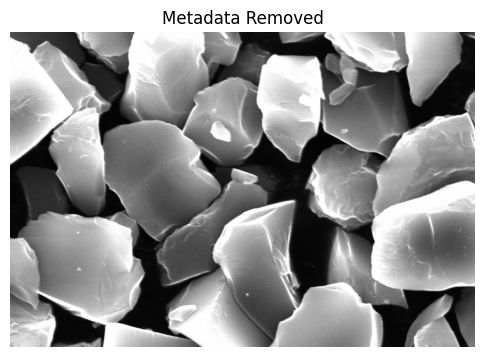

In [ ]:
cropped = original_image[:metadata_top,:]

plt.figure(figsize=(6,6))
plt.imshow(cropped)
plt.title("Metadata Removed")
plt.axis("off")

In [ ]:
clean_image = cropped.copy()

h_img,w_img,_ = clean_image.shape

clean_image[int(0.85*h_img):h_img,0:int(0.25*w_img)] = 0

In [ ]:
# -------- Detect scale bar length automatically --------
gray_scale = cv2.cvtColor(original_image, cv2.COLOR_RGB2GRAY)

# detect bright objects (scale bar)
_, thresh = cv2.threshold(gray_scale, 200, 255, cv2.THRESH_BINARY)

# morphological operation to keep horizontal bars
kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(40,3))
horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

contours,_ = cv2.findContours(horizontal, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

scale_length_pixels = None

h_img = original_image.shape[0]

for c in contours:
    x,y,w,h = cv2.boundingRect(c)

    aspect_ratio = w / max(h,1)

    # scale bars are long horizontal rectangles near bottom
    if aspect_ratio > 5 and w > 50 and y > 0.7*h_img:
        scale_length_pixels = w
        break

print("Scale bar length (pixels):", scale_length_pixels)

Scale bar length (pixels): 1019


In [ ]:
if scale_length_pixels is None:
    raise ValueError("Scale bar not detected")

(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

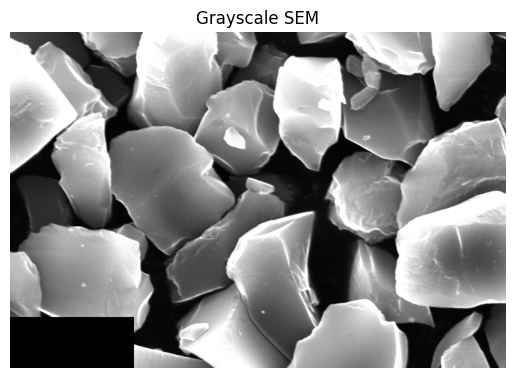

In [ ]:
gray_clean = cv2.cvtColor(clean_image,cv2.COLOR_RGB2GRAY)

plt.imshow(gray_clean,cmap="gray")
plt.title("Grayscale SEM")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

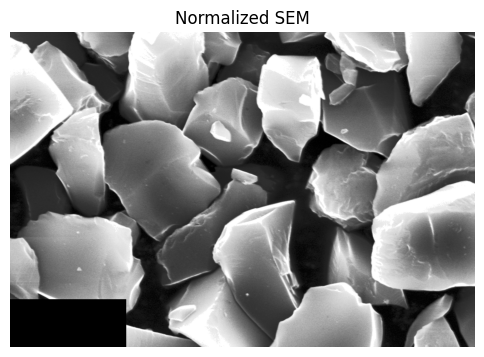

In [ ]:
gray_clean = cv2.equalizeHist(gray_clean)

plt.figure(figsize=(6,6))
plt.imshow(gray_clean,cmap="gray")
plt.title("Normalized SEM")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

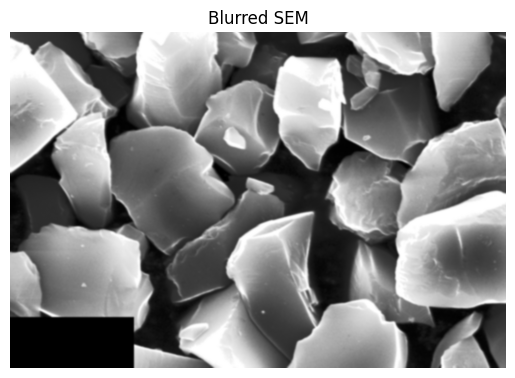

In [ ]:
blur = cv2.GaussianBlur(gray_clean,(7,7),0)

plt.imshow(blur,cmap="gray")
plt.title("Blurred SEM")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

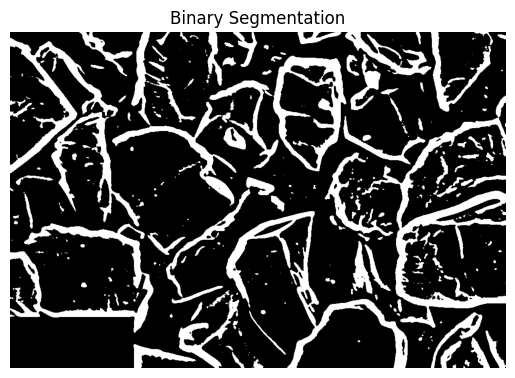

In [ ]:
binary = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    51,
    -5
)

plt.imshow(binary,cmap="gray")
plt.title("Binary Segmentation")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

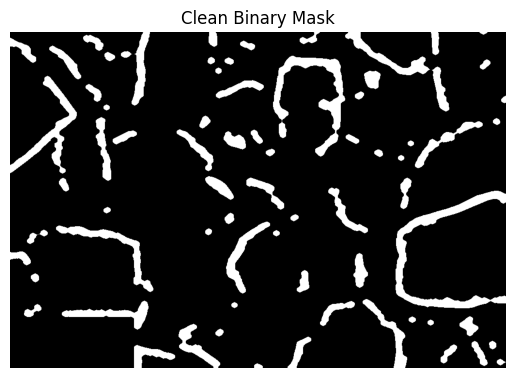

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))

binary = cv2.morphologyEx(binary,cv2.MORPH_OPEN,kernel,iterations=2)
binary = cv2.morphologyEx(binary,cv2.MORPH_CLOSE,kernel,iterations=2)

plt.imshow(binary,cmap="gray")
plt.title("Clean Binary Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

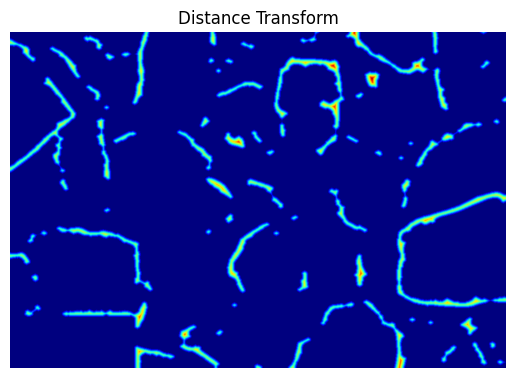

In [ ]:
dist = cv2.distanceTransform(binary,cv2.DIST_L2,5)

plt.imshow(dist,cmap="jet")
plt.title("Distance Transform")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

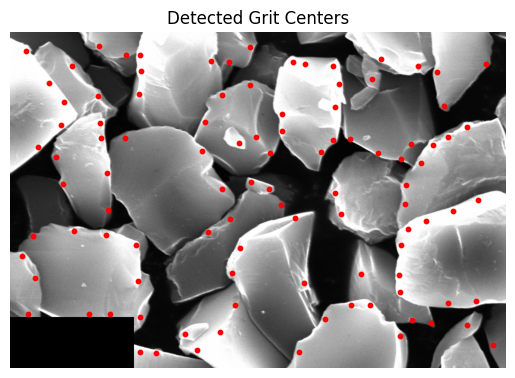

In [ ]:
from skimage.feature import peak_local_max

coords = peak_local_max(
    dist,
    min_distance=25,
    threshold_rel=0.2
)

plt.imshow(clean_image)

ys, xs = coords[:,0], coords[:,1]

plt.scatter(xs,ys,c="red",s=10)

plt.title("Detected Grit Centers")
plt.axis("off")

In [ ]:
from scipy import ndimage

markers = np.zeros(dist.shape,dtype=int)

for i,(y,x) in enumerate(coords):
    markers[y,x] = i+1

markers = ndimage.label(markers)[0]

print("Detected centers:",markers.max())

Detected centers: 102


(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

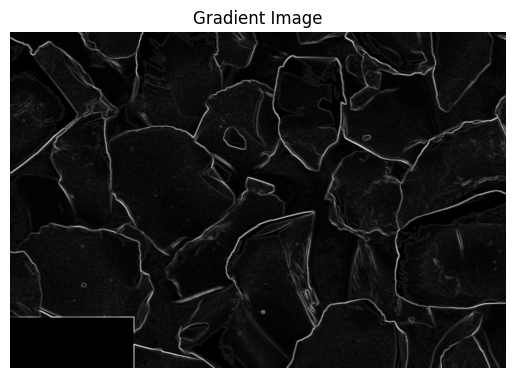

In [ ]:
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

# compute gradient image
gradient = cv2.morphologyEx(
    gray_clean,
    cv2.MORPH_GRADIENT,
    np.ones((3,3),np.uint8)
)

plt.imshow(gradient,cmap='gray')
plt.title("Gradient Image")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

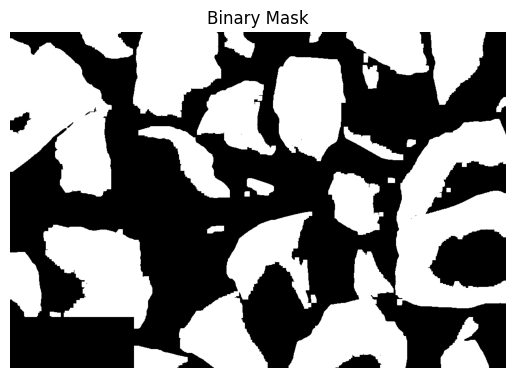

In [ ]:
_, binary = cv2.threshold(
    gray_clean,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    np.ones((5,5),np.uint8),
    iterations=2
)

plt.imshow(binary,cmap='gray')
plt.title("Binary Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

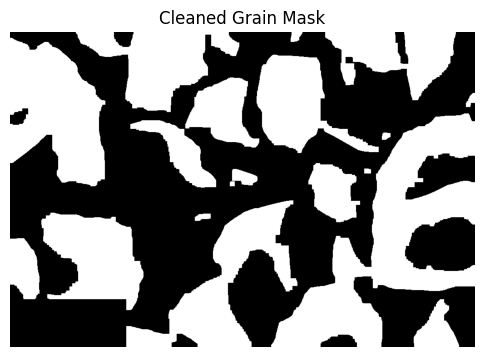

In [ ]:
from scipy import ndimage

# fill holes inside grains
binary = ndimage.binary_fill_holes(binary).astype(np.uint8)*255

# remove small internal regions
kernel = np.ones((7,7),np.uint8)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

# smooth edges
binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

plt.figure(figsize=(6,6))
plt.imshow(binary,cmap="gray")
plt.title("Cleaned Grain Mask")
plt.axis("off")

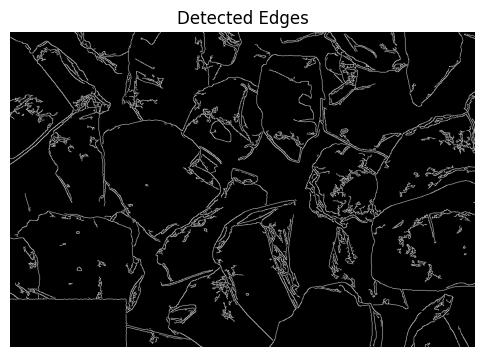

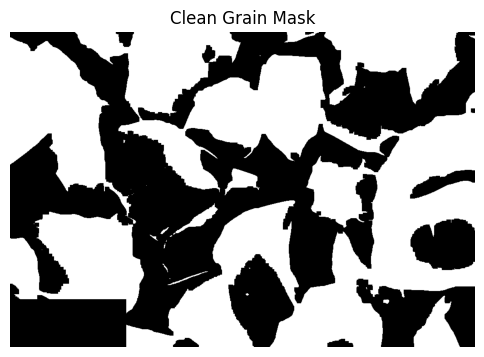

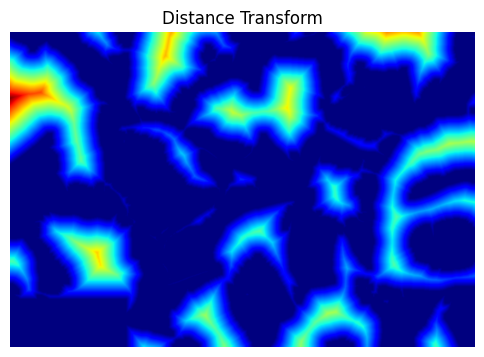

In [ ]:
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

# ---------- STEP 1: edge detection ----------
edges = cv2.Canny(gray_clean, 40, 160)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap='gray')
plt.title("Detected Edges")
plt.axis("off")


# ---------- STEP 2: create grain mask ----------
_, binary = cv2.threshold(
    gray_clean,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# remove small noise
kernel = np.ones((5,5),np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# fill holes inside grains
binary = ndimage.binary_fill_holes(binary).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(binary,cmap='gray')
plt.title("Clean Grain Mask")
plt.axis("off")


# ---------- STEP 3: distance transform ----------
dist = cv2.distanceTransform(binary, cv2.DIST_L2,5)

plt.figure(figsize=(6,6))
plt.imshow(dist,cmap='jet')
plt.title("Distance Transform")
plt.axis("off")


# ---------- STEP 4: detect grain centers ----------
coords = peak_local_max(
    dist,
    min_distance=30,
    labels=binary
)

mask = np.zeros(dist.shape,dtype=bool)
mask[tuple(coords.T)] = True

markers,_ = ndimage.label(mask)


# ---------- STEP 5: watershed using edges ----------
labels = watershed(
    edges,
    markers,
    mask=binary
)

In [ ]:
regions = regionprops(labels)

In [ ]:
from skimage.measure import regionprops

regions = regionprops(labels)

grit_masks = []

for r in regions:

    if r.area < 800:
        continue

    mask = (labels == r.label)

    grit_masks.append(mask)

print("Detected grits:", len(grit_masks))

Detected grits: 28


(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

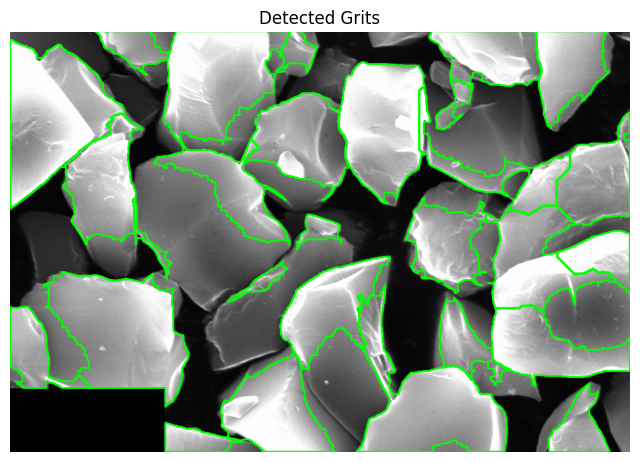

In [ ]:
detected_image = clean_image.copy()

for mask in grit_masks:

    mask_uint8 = (mask.astype(np.uint8) * 255)

    contours,_ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        continue

    cnt = max(contours, key=cv2.contourArea)

    cv2.drawContours(
        detected_image,
        [cnt],
        -1,
        (0,255,0),
        2
    )

plt.figure(figsize=(8,8))
plt.imshow(detected_image)
plt.title("Detected Grits")
plt.axis("off")

In [ ]:
# -------- Convert pixels to microns --------
scale_bar_microns = 2.0  # SEM shows 2 µm scale

microns_per_pixel = scale_bar_microns / scale_length_pixels

print("Microns per pixel:", microns_per_pixel)

Microns per pixel: 0.001962708537782139


(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

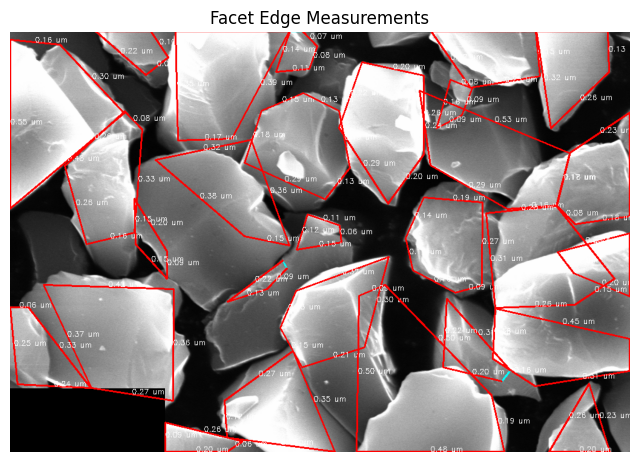

In [ ]:
facet_image = clean_image.copy()

for mask in grit_masks:

    mask_uint8 = (mask.astype(np.uint8) * 255)

    contours,_ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        continue

    cnt = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(cnt)

    epsilon = 0.04 * cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, epsilon, True)

    cv2.drawContours(facet_image,[approx],-1,(0,255,255),2)

    for i in range(len(approx)):

        p1 = approx[i][0]
        p2 = approx[(i+1)%len(approx)][0]

        x1,y1 = p1
        x2,y2 = p2

        # length in pixels
        length_pixels = np.sqrt((x2-x1)**2 + (y2-y1)**2)

        # convert to microns
        length_um = length_pixels * microns_per_pixel

        # ignore tiny edges
        if length_um < 0.05:
            continue

        cv2.line(
            facet_image,
            (x1,y1),
            (x2,y2),
            (255,0,0),
            2
        )

        mx = int((x1+x2)/2)
        my = int((y1+y2)/2)

        label = f"{length_um:.2f} um"

        cv2.putText(
            facet_image,
            label,
            (mx,my),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (255,255,255),
            1
        )

plt.figure(figsize=(8,8))
plt.imshow(facet_image)
plt.title("Facet Edge Measurements")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

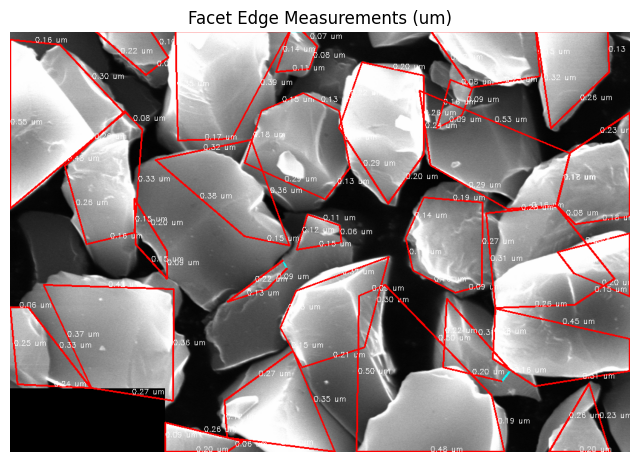

In [ ]:
facet_image = clean_image.copy()

for mask in grit_masks:

    mask_uint8 = (mask.astype(np.uint8) * 255)

    contours,_ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        continue

    cnt = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(cnt)

    epsilon = 0.04 * cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, epsilon, True)

    cv2.drawContours(facet_image,[approx],-1,(0,255,255),2)

    for i in range(len(approx)):

        p1 = approx[i][0]
        p2 = approx[(i+1)%len(approx)][0]

        x1,y1 = p1
        x2,y2 = p2

        length_pixels = np.sqrt((x2-x1)**2 + (y2-y1)**2)

        length_um = length_pixels * microns_per_pixel

        if length_um < 0.05:
            continue

        cv2.line(facet_image,(x1,y1),(x2,y2),(255,0,0),2)

        mx = int((x1+x2)/2)
        my = int((y1+y2)/2)

        label = f"{length_um:.2f} um"

        cv2.putText(
            facet_image,
            label,
            (mx,my),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (255,255,255),
            1
        )

plt.figure(figsize=(8,8))
plt.imshow(facet_image)
plt.title("Facet Edge Measurements (um)")
plt.axis("off")


(np.float64(-0.5), np.float64(1023.5), np.float64(693.5), np.float64(-0.5))

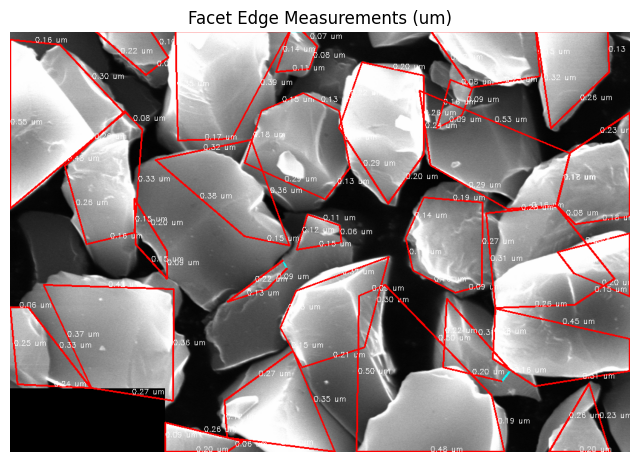

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(facet_image)
plt.title("Facet Edge Measurements (um)")
plt.axis("off")

In [ ]:
##now the construction of CAD will the there

In [ ]:
!pip install trimesh shapely


In [ ]:
!pip install mapbox-earcut


In [ ]:
!pip install mapbox-earcut shapely trimesh


In [ ]:
import trimesh
import mapbox_earcut
from shapely.geometry import Polygon


In [ ]:
import trimesh
import numpy as np
from shapely.geometry import Polygon

solids = []

for mask in grit_masks:

    mask_uint8 = (mask.astype(np.uint8) * 255)

    contours,_ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        continue

    cnt = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(cnt)

    epsilon = 0.04 * cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, epsilon, True)

    # -----------------------------
    # base polygon in microns
    # -----------------------------

    base_points = []

    for p in approx:
        x,y = p[0]

        base_points.append([
            x * microns_per_pixel,
            y * microns_per_pixel
        ])

    if len(base_points) < 3:
        continue

    polygon = Polygon(base_points)

    min_x, min_y, max_x, max_y = polygon.bounds

    grain_width = max(max_x-min_x, max_y-min_y)

    # realistic grain height
    height = grain_width * np.random.uniform(0.35,0.55)

    # -----------------------------
    # extrude base polygon
    # -----------------------------

    mesh = trimesh.creation.extrude_polygon(
        polygon,
        height
    )

    # -----------------------------
    # distort vertices to create facets
    # -----------------------------

    verts = mesh.vertices.copy()

    for i,v in enumerate(verts):

        # only distort upper vertices
        if v[2] > height * 0.3:

            verts[i][0] += np.random.uniform(-0.15,0.15) * grain_width
            verts[i][1] += np.random.uniform(-0.15,0.15) * grain_width
            verts[i][2] += np.random.uniform(-0.2,0.2) * height

    mesh.vertices = verts

    # -----------------------------
    # random grain orientation
    # -----------------------------

    angles = np.random.uniform(0, np.pi, 3)

    Rx = trimesh.transformations.rotation_matrix(
        angles[0],[1,0,0]
    )

    Ry = trimesh.transformations.rotation_matrix(
        angles[1],[0,1,0]
    )

    Rz = trimesh.transformations.rotation_matrix(
        angles[2],[0,0,1]
    )

    mesh.apply_transform(Rx)
    mesh.apply_transform(Ry)
    mesh.apply_transform(Rz)

    solids.append(mesh)


    plane_grains = []

spacing = 5  # microns

cols = int(np.ceil(np.sqrt(len(solids))))

row = 0
col = 0

for i, mesh in enumerate(solids):

    g = mesh.copy()

    # bring lowest point to Z = 0
    min_z = g.vertices[:,2].min()
    g.vertices[:,2] -= min_z

    # compute size
    min_x = g.vertices[:,0].min()
    max_x = g.vertices[:,0].max()

    min_y = g.vertices[:,1].min()
    max_y = g.vertices[:,1].max()

    width = max_x - min_x
    depth = max_y - min_y

    # compute grid position
    x_offset = col * (width + spacing)
    y_offset = row * (depth + spacing)

    g.vertices[:,0] += x_offset - min_x
    g.vertices[:,1] += y_offset - min_y

    plane_grains.append(g)

    col += 1

    if col >= cols:
        col = 0
        row += 1

In [ ]:
print("Generated grains:", len(solids))

if len(solids) > 0:

    combined = trimesh.util.concatenate(solids)

    combined.export("grains.stl")

    print("Export successful")

else:
    print("No grains generated")

Generated grains: 28
Export successful


In [ ]:
combined = trimesh.util.concatenate(solids)


In [ ]:
combined.export("grit_model.stl")


b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80\x01\x00\x00\x9b\xf3\xc3>\x1f\xdf\n\xbf\x15r?\xbf8Q\xd4\xbeb\xb5T\xbc\xc6\xabO\xbe\x17\x99\xe3\xbe5\xa5K=K\xf1\x86\xbe\xf0\xcf\xb7\xbe\x97\xa3\xd6=A\xfe\x84\xbe\x00\x00\x9b\xf3\xc3>\x1f\xdf\n\xbf\x15r?\xbf\xf0\xcf\xb7\xbe\x97\xa3\xd6=A\xfe\x84\xbeMm_\xbe\xdfr\x82=\xcf\xa7!\xbe8Q\xd4\xbeb\xb5T\xbc\xc6\xabO\xbe\x00\x00\xbc\\S\xbe\xa5\xea\x1a?9\xd6D?\xd9\xe7\xc0\xbe\x14\xd1\x1d>\xcb\x87T\xbe1B\xe4\xbe\x15\xb8\xee=\x8d>I\xbe\x03z\xd5\xbe\xb1\x9a9=-\xe3\x07\xbe\x00\x00\xffq\xb2\xbe\x94{\x1d?\x8e\t5?\x03z\xd5\xbe\xb1\x9a9=-\xe3\x07\xbe(<k\xbe0G\xf1=\x9d\xf5\xd3\xbd\xd9\xe7\xc0\xbe\x14\xd1\x1d>\xcb\x87T\xbe\x00\x00h\xeft\xbfL\xc3s\xbe\x13\x11+>\x03z\xd5\xbe\xb1\x9a9=-\xe3\

In [ ]:
plane = trimesh.util.concatenate(plane_grains)
plane.export("grains_on_plane.stl")

b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80\x01\x00\x00\x9b\xf3\xc3>\x1f\xdf\n\xbf\x15r?\xbf\x96\x0f\xff<\x00\x00\x00\x00C\xdbx=\xcc\x19\xa9:Gi\x80=\x00\x00\x00\x00\x05\xc9\xb1=C:\xf1=\x02\x85y;\x00\x00\x9b\xf3\xc3>\x1f\xdf\n\xbf\x15r?\xbf\x05\xc9\xb1=C:\xf1=\x02\x85y;\x15\x17i>\x8b\t\x9d=\x8fu\xd8=\x96\x0f\xff<\x00\x00\x00\x00C\xdbx=\x00\x00\xbc\\S\xbe\xa5\xea\x1a?9\xd6D?ai\x8d=j\x1c+>0ke=\x00\x00\x00\x00`\xa7\x04>\x13H\x89=\xe0\x82\xec<\n\xc8n=i\xff\x05>\x00\x00\xffq\xb2\xbe\x94{\x1d?\x8e\t5?\xe0\x82\xec<\n\xc8n=i\xff\x05>:H]>\xee\xee\x05>\xc8\xe7#>ai\x8d=j\x1c+>0ke=\x00\x00h\xeft\xbfL\xc3s\xbe\x13\x11+>\xe0\x82\xec<\n\xc8n=i\xff\x05>\x00\x00\x00\x00`\xa7\x04>\x13H\x89=\x96\x0f\xff<\x00\x00\x00\x00C\xdbx=\

In [ ]:
from google.colab import files
files.download("grit_model.stl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("grains_on_plane.stl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Total grains detected:", len(solids))

Total grains detected: 28


In [ ]:
for i, g in enumerate(solids[:5]):
    print("grain", i, "vertices:", len(g.vertices))

grain 0 vertices: 8
grain 1 vertices: 10
grain 2 vertices: 8
grain 3 vertices: 8
grain 4 vertices: 8


In [ ]:
import trimesh
import numpy as np

# -----------------------------------------
# 1. Inputs (in mm)
# -----------------------------------------

wheel_diameter_mm = float(input("Enter grinding wheel diameter (mm): "))
wheel_width_mm = float(input("Enter grinding wheel width (mm): "))

# convert to microns
wheel_radius = (wheel_diameter_mm * 1000) / 2
wheel_width = wheel_width_mm * 1000

print("Wheel radius (µm):", wheel_radius)
print("Wheel width (µm):", wheel_width)

# -----------------------------------------
# 2. Create wheel body
# -----------------------------------------

wheel = trimesh.creation.cylinder(
    radius=wheel_radius,
    height=wheel_width,
    sections=128
)

# rotate wheel axis to X direction
R = trimesh.transformations.rotation_matrix(
    np.pi/2,
    [0,1,0]
)

wheel.apply_transform(R)

placed_grains = []

# -----------------------------------------
# 3. Grain density model
# -----------------------------------------

grain_density = float(input("Enter grain density (grains per mm²): "))


surface_area_mm2 = 2 * np.pi * (wheel_radius/1000) * (wheel_width/1000)

num_grains = int(surface_area_mm2 * grain_density)

print("Wheel surface area (mm²):", surface_area_mm2)
print("Total grains to generate:", num_grains)
# -----------------------------------------
# 4. Place grains
# -----------------------------------------

for i in range(num_grains):

    grain = np.random.choice(solids)
    g = grain.copy()

    # center grain
    mesh_center = g.bounds.mean(axis=0)
    g.vertices -= mesh_center

    # random orientation
    angles = np.random.uniform(0, 2*np.pi, 3)
    R = trimesh.transformations.euler_matrix(*angles)
    g.apply_transform(R)

    # grain radial size
    radial_dist = np.sqrt(g.vertices[:,1]**2 + g.vertices[:,2]**2)
    grain_radius = radial_dist.max()

    # embed grain into bond
    embed_fraction = np.random.uniform(0.3, 0.6)

    r = wheel_radius - grain_radius * embed_fraction

    # angular location
    theta = np.random.uniform(0, 2*np.pi)

    y = r * np.cos(theta)
    z = r * np.sin(theta)

    # position along wheel width
    x = np.random.uniform(-wheel_width/2, wheel_width/2)

    g.apply_translation([x,y,z])

    placed_grains.append(g)

# -----------------------------------------
# 5. Combine meshes
# -----------------------------------------

all_meshes = [wheel] + placed_grains

grinding_wheel = trimesh.util.concatenate(all_meshes)

# -----------------------------------------
# 6. Export STL
# -----------------------------------------

grinding_wheel.export("grinding_wheel_perfect.stl")

print(f"Success! {len(placed_grains)} grains placed on wheel surface.")

Enter grinding wheel diameter (mm): 2
Enter grinding wheel width (mm): 1
Wheel radius (µm): 1000.0
Wheel width (µm): 1000.0
Enter grain density (grains per mm²): 2
Wheel surface area (mm²): 6.283185307179586
Total grains to generate: 12
Success! 12 grains placed on wheel surface.


In [ ]:
from google.colab import files
files.download("grinding_wheel_perfect.stl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>